# Segmenter Training and Debugging

The segmentation code now lives in `src/uno_vision/segmentation/`.
This notebook keeps the exploration loop short: load package helpers, inspect the dataset, train the model, and visualize scene-level predictions.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split

from uno_vision.paths import SEGMENTER_MODELS_DIR, TEST_IMAGES_DIR
from uno_vision.segmentation.data import IMG_SIZE, SegDataset, collect_segmentation_pairs
from uno_vision.segmentation.inference import segment_image_path
from uno_vision.segmentation.model import UNetSmall
from uno_vision.segmentation.training import train_segmenter

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = UNetSmall()
param_count = sum(param.numel() for param in model.parameters())
print(f"torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"UNetSmall parameters: {param_count:,}")
print(f"Model output directory: {SEGMENTER_MODELS_DIR}")

torch: 2.11.0+cu128
CUDA available: True
UNetSmall parameters: 1,928,417
Model output directory: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter


In [2]:
pairs = collect_segmentation_pairs()
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

train_ds = SegDataset(train_pairs, augment=True)
val_ds = SegDataset(val_pairs, augment=False)

print(f"Total pairs: {len(pairs)}")
print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs:   {len(val_pairs)}")
print(f"Image size used by the dataset: {IMG_SIZE}")

Total pairs: 1134
Train pairs: 907
Val pairs:   227
Image size used by the dataset: 256


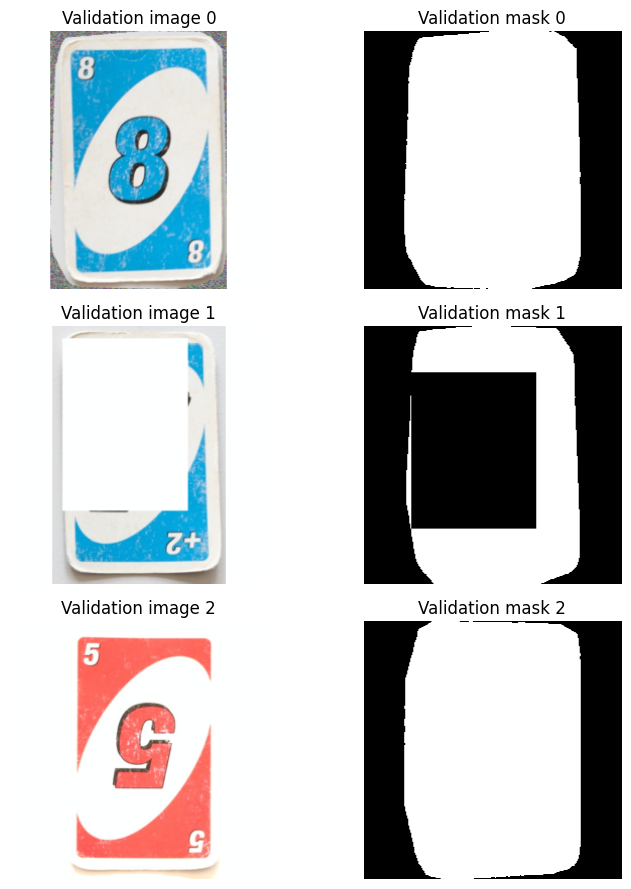

In [3]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def tensor_to_rgb(img_t):
    img = img_t.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

preview_count = min(3, len(val_ds))
fig, axes = plt.subplots(preview_count, 2, figsize=(8, 3 * preview_count))
axes = np.atleast_2d(axes)

for row_idx in range(preview_count):
    img_t, mask_t = val_ds[row_idx]
    axes[row_idx, 0].imshow(tensor_to_rgb(img_t))
    axes[row_idx, 0].set_title(f"Validation image {row_idx}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask_t[0].numpy(), cmap="gray")
    axes[row_idx, 1].set_title(f"Validation mask {row_idx}")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

In [4]:
EPOCHS = 25
BATCH_SIZE = 8

history = train_segmenter(
    pairs=pairs,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    random_state=SEED,
)

print(f"Saved model: {history.model_path}")
print(f"Best val IoU: {max(history.val_ious):.4f}")

19:50:07 | INFO | Segmenter training start | device=cuda | train_samples=907 | val_samples=227 | batch_size=8 | num_workers=4 | amp=True
19:50:48 | INFO | Segmenter epoch 1/25 | train=38.14s | val=2.71s | total=40.85s | train_loss=0.2311 | val_loss=0.2952 | train_iou=0.8634 | val_iou=0.8113
19:50:51 | INFO | Segmenter epoch 2/25 | train=3.04s | val=0.23s | total=3.27s | train_loss=0.1125 | val_loss=0.1179 | train_iou=0.9202 | val_iou=0.9119
19:50:54 | INFO | Segmenter epoch 3/25 | train=3.00s | val=0.24s | total=3.23s | train_loss=0.0950 | val_loss=0.0845 | train_iou=0.9273 | val_iou=0.9404
19:50:57 | INFO | Segmenter epoch 4/25 | train=2.98s | val=0.24s | total=3.21s | train_loss=0.0845 | val_loss=0.0866 | train_iou=0.9352 | val_iou=0.9324
19:51:01 | INFO | Segmenter epoch 5/25 | train=2.96s | val=0.24s | total=3.21s | train_loss=0.0803 | val_loss=0.0927 | train_iou=0.9375 | val_iou=0.9318
19:51:04 | INFO | Segmenter epoch 6/25 | train=3.02s | val=0.24s | total=3.26s | train_loss=0.07

Saved model: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\segmenter_unet_small.pth
Best val IoU: 0.9522


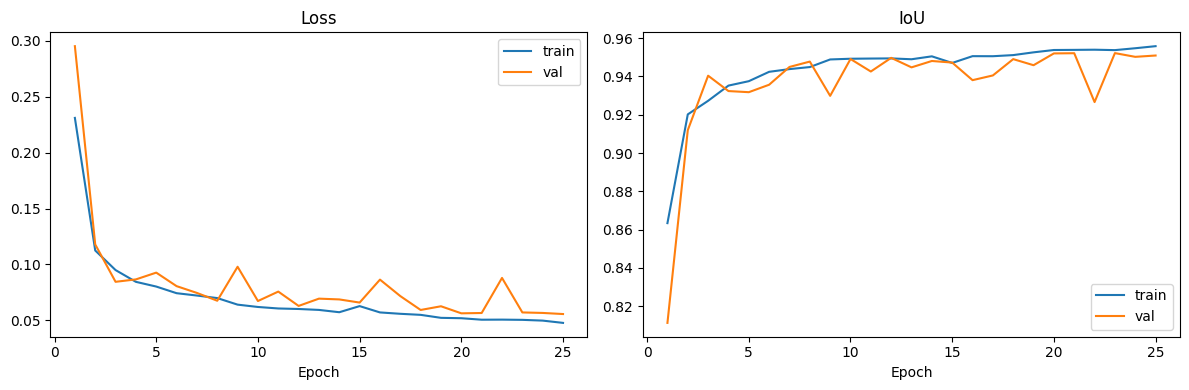

In [5]:
if "history" not in globals():
    raise RuntimeError("Run the training cell first so 'history' is available.")

epochs = range(1, len(history.train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.train_losses, label="train")
axes[0].plot(epochs, history.val_losses, label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history.train_ious, label="train")
axes[1].plot(epochs, history.val_ious, label="val")
axes[1].set_title("IoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

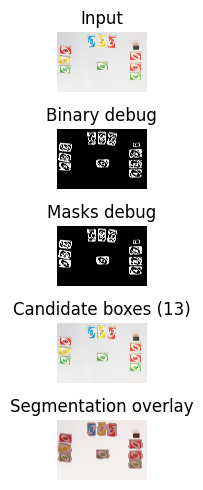

Model loaded from: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\segmenter_unet_small.pth
Scene image: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\test_images\L1000793.jpg


In [ ]:
scene_path = TEST_IMAGES_DIR / "L1000793.jpg"
img_bgr, global_prob, boxes, binary_dbg, masks_dbg, model_path = segment_image_path(scene_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
boxed = img_rgb.copy()
for x, y, w, h in boxes:
    cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 2)

mask_bin = (global_prob > 0.5).astype(np.uint8)

fig, axes = plt.subplots(5, 1, figsize=(24, 50))
axes[0].imshow(img_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(binary_dbg, cmap="gray")
axes[1].set_title("Binary debug")
axes[1].axis("off")

axes[2].imshow(masks_dbg, cmap="gray")
axes[2].set_title("Masks debug")
axes[2].axis("off")

axes[3].imshow(boxed)
axes[3].set_title(f"Candidate boxes ({len(boxes)})")
axes[3].axis("off")

axes[4].imshow(img_rgb)
axes[4].imshow(mask_bin, cmap="Reds", alpha=0.4)
axes[4].set_title("Segmentation overlay")
axes[4].axis("off")

plt.tight_layout()
plt.show()

print(f"Model loaded from: {model_path}")
print(f"Scene image: {scene_path}")